In [77]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import spearmanr, kendalltau
from types import FunctionType
from pprint import pprint
import matplotlib.patches as mpatches

plt.style.use(["science", "grid", "ieee"])

In [34]:
DATASETS = [
    "fb-wosn-friends",
    "ca-cit-HepTh",
    "comm-linux-kernel-reply",
    "ia-enron-email-all",
]

SHORT_NAMES = {
    "fb-wosn-friends": "facebook",
    "comm-linux-kernel-reply": "linux",
    "ia-enron-email-all": "enron",
    "ca-cit-HepTh": "citation",
}

TIME_STAMPS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
FILE_NAMES = {
    ds: {alpha: f"distances/{ds}_{int(alpha*100)}%" for alpha in TIME_STAMPS}
    for ds in DATASETS
}

FILE_NAMES

{'fb-wosn-friends': {0.5: 'distances/fb-wosn-friends_50%',
  0.6: 'distances/fb-wosn-friends_60%',
  0.7: 'distances/fb-wosn-friends_70%',
  0.8: 'distances/fb-wosn-friends_80%',
  0.9: 'distances/fb-wosn-friends_90%',
  1.0: 'distances/fb-wosn-friends_100%'},
 'ca-cit-HepTh': {0.5: 'distances/ca-cit-HepTh_50%',
  0.6: 'distances/ca-cit-HepTh_60%',
  0.7: 'distances/ca-cit-HepTh_70%',
  0.8: 'distances/ca-cit-HepTh_80%',
  0.9: 'distances/ca-cit-HepTh_90%',
  1.0: 'distances/ca-cit-HepTh_100%'},
 'comm-linux-kernel-reply': {0.5: 'distances/comm-linux-kernel-reply_50%',
  0.6: 'distances/comm-linux-kernel-reply_60%',
  0.7: 'distances/comm-linux-kernel-reply_70%',
  0.8: 'distances/comm-linux-kernel-reply_80%',
  0.9: 'distances/comm-linux-kernel-reply_90%',
  1.0: 'distances/comm-linux-kernel-reply_100%'},
 'ia-enron-email-all': {0.5: 'distances/ia-enron-email-all_50%',
  0.6: 'distances/ia-enron-email-all_60%',
  0.7: 'distances/ia-enron-email-all_70%',
  0.8: 'distances/ia-enron-emai

In [35]:
def harmonic_centrality(
    layers: list[int | float], trunc: int = np.inf
) -> np.ndarray:
    HC = np.zeros(len(layers))
    for u, layer in enumerate(layers):
        for d in range(1, len(layer)):
            if d > trunc:
                break
            HC[u] += layer[d] / d
    return HC

In [36]:
def top_vertices(HC: np.ndarray, k: int) -> list[int]:
    return [i for i, _ in sorted(enumerate(HC), key=lambda x: x[1], reverse=True)[:k]]

In [37]:
def load_layers(
    dataset: str, alpha: float = 1.0, apx: bool = False
) -> list[int | float]:
    fname = FILE_NAMES[dataset][alpha] + (".dist" if not apx else ".apxdist")
    with open(fname, "r") as f:
        # return [list(map(int if not apx else float, l.split())) for l in f.readlines()]
        if not apx:
            return [list(map(int, l.split())) for l in f.readlines()]
        else:
            layers = [list(map(float, l.split())) for l in f.readlines()]
            for i in range(len(layers)):
                layers[i][2] -= layers[i][1]
            return layers


In [38]:
def truncated_harmonic_centrality(
    dataset: str,
    alpha: float = 1.0,
    p: float = 0.05,
) -> np.ndarray:
    layers = load_layers(dataset, alpha)
    hc = harmonic_centrality(layers)
    k = int(len(layers) * p)
    top_k = top_vertices(hc, k)

    diam = max([len(layers[i]) for i in top_k]) - 1

    M = np.zeros((k, diam))
    for i, u in enumerate(top_k):
        for d in range(len(layers[u]) - 1):
            M[i, d:] += layers[u][d + 1] / (d + 1)

    return M

In [39]:
def apx_centrality(dataset: str, alpha: float = 1.0) -> np.ndarray:
    """
    Compute the apx-truncated-harmonic centrality for the given `dataset`, at a given timestamp `alpha`.
    """
    layers = load_layers(dataset, alpha, apx=True)
    return harmonic_centrality(layers)

In [40]:
def correlation(
    centralities: np.ndarray, correlation_function: FunctionType = spearmanr
) -> list[float]:
    return [
        correlation_function(centralities[:, d], centralities[:, -1]).statistic
        for d in range(len(centralities[0]))
    ]

# PLOT1

In [41]:
p = 0.05
time_stamps = [0.6, 0.8, 1.0]

centralities = {
    ds: {alpha: truncated_harmonic_centrality(ds, alpha, p) for alpha in time_stamps}
    for ds in DATASETS
}

In [42]:
def plot_truncated_distances(correlation_function: FunctionType = spearmanr):
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(4, 2))
    fig.subplots_adjust(wspace=0.1)
    d = 7
    markers = dict(zip(DATASETS, ["o", "d", "x", "v"]))
    colors = dict(zip(DATASETS, ["k", "r", "b", "g"]))
    linestyles = dict(zip(DATASETS, ["-", "--", ":", "-."]))

    for i, alpha in enumerate(time_stamps):
        for j, ds in enumerate(DATASETS):
            y = correlation(centralities[ds][alpha], correlation_function)
            ax[i].plot(
                y[:d],
                color=colors[ds],
                marker=markers[ds],
                markersize=3,
                # label=SHORT_NAMES[ds],
            )

        ax[i].grid(True)
        # ax[i].legend()
        ax[i].set_xticks(range(d), [x + 1 for x in range(d)])
        ax[i].set_title(f"{int(alpha*100)}\%")

        fig.legend(
            handles=[
                plt.Line2D(
                    [0],
                    [0],
                    label=SHORT_NAMES[ds],
                    color=colors[ds],
                    marker=markers[ds],
                    linestyle=linestyles[ds],
                    markersize=4,
                )
                for ds in DATASETS
            ],
            loc="upper center",
            ncol=4,
            bbox_to_anchor=(0.5, 1.1),
            fontsize=7,
        )

    ax[0].set_ylabel(
        "Spearman correlation"
        if correlation_function == spearmanr
        else "Kendall's $\\tau$ coefficient"
    )
    ax[1].set_xlabel("Distance")

    plt.show()

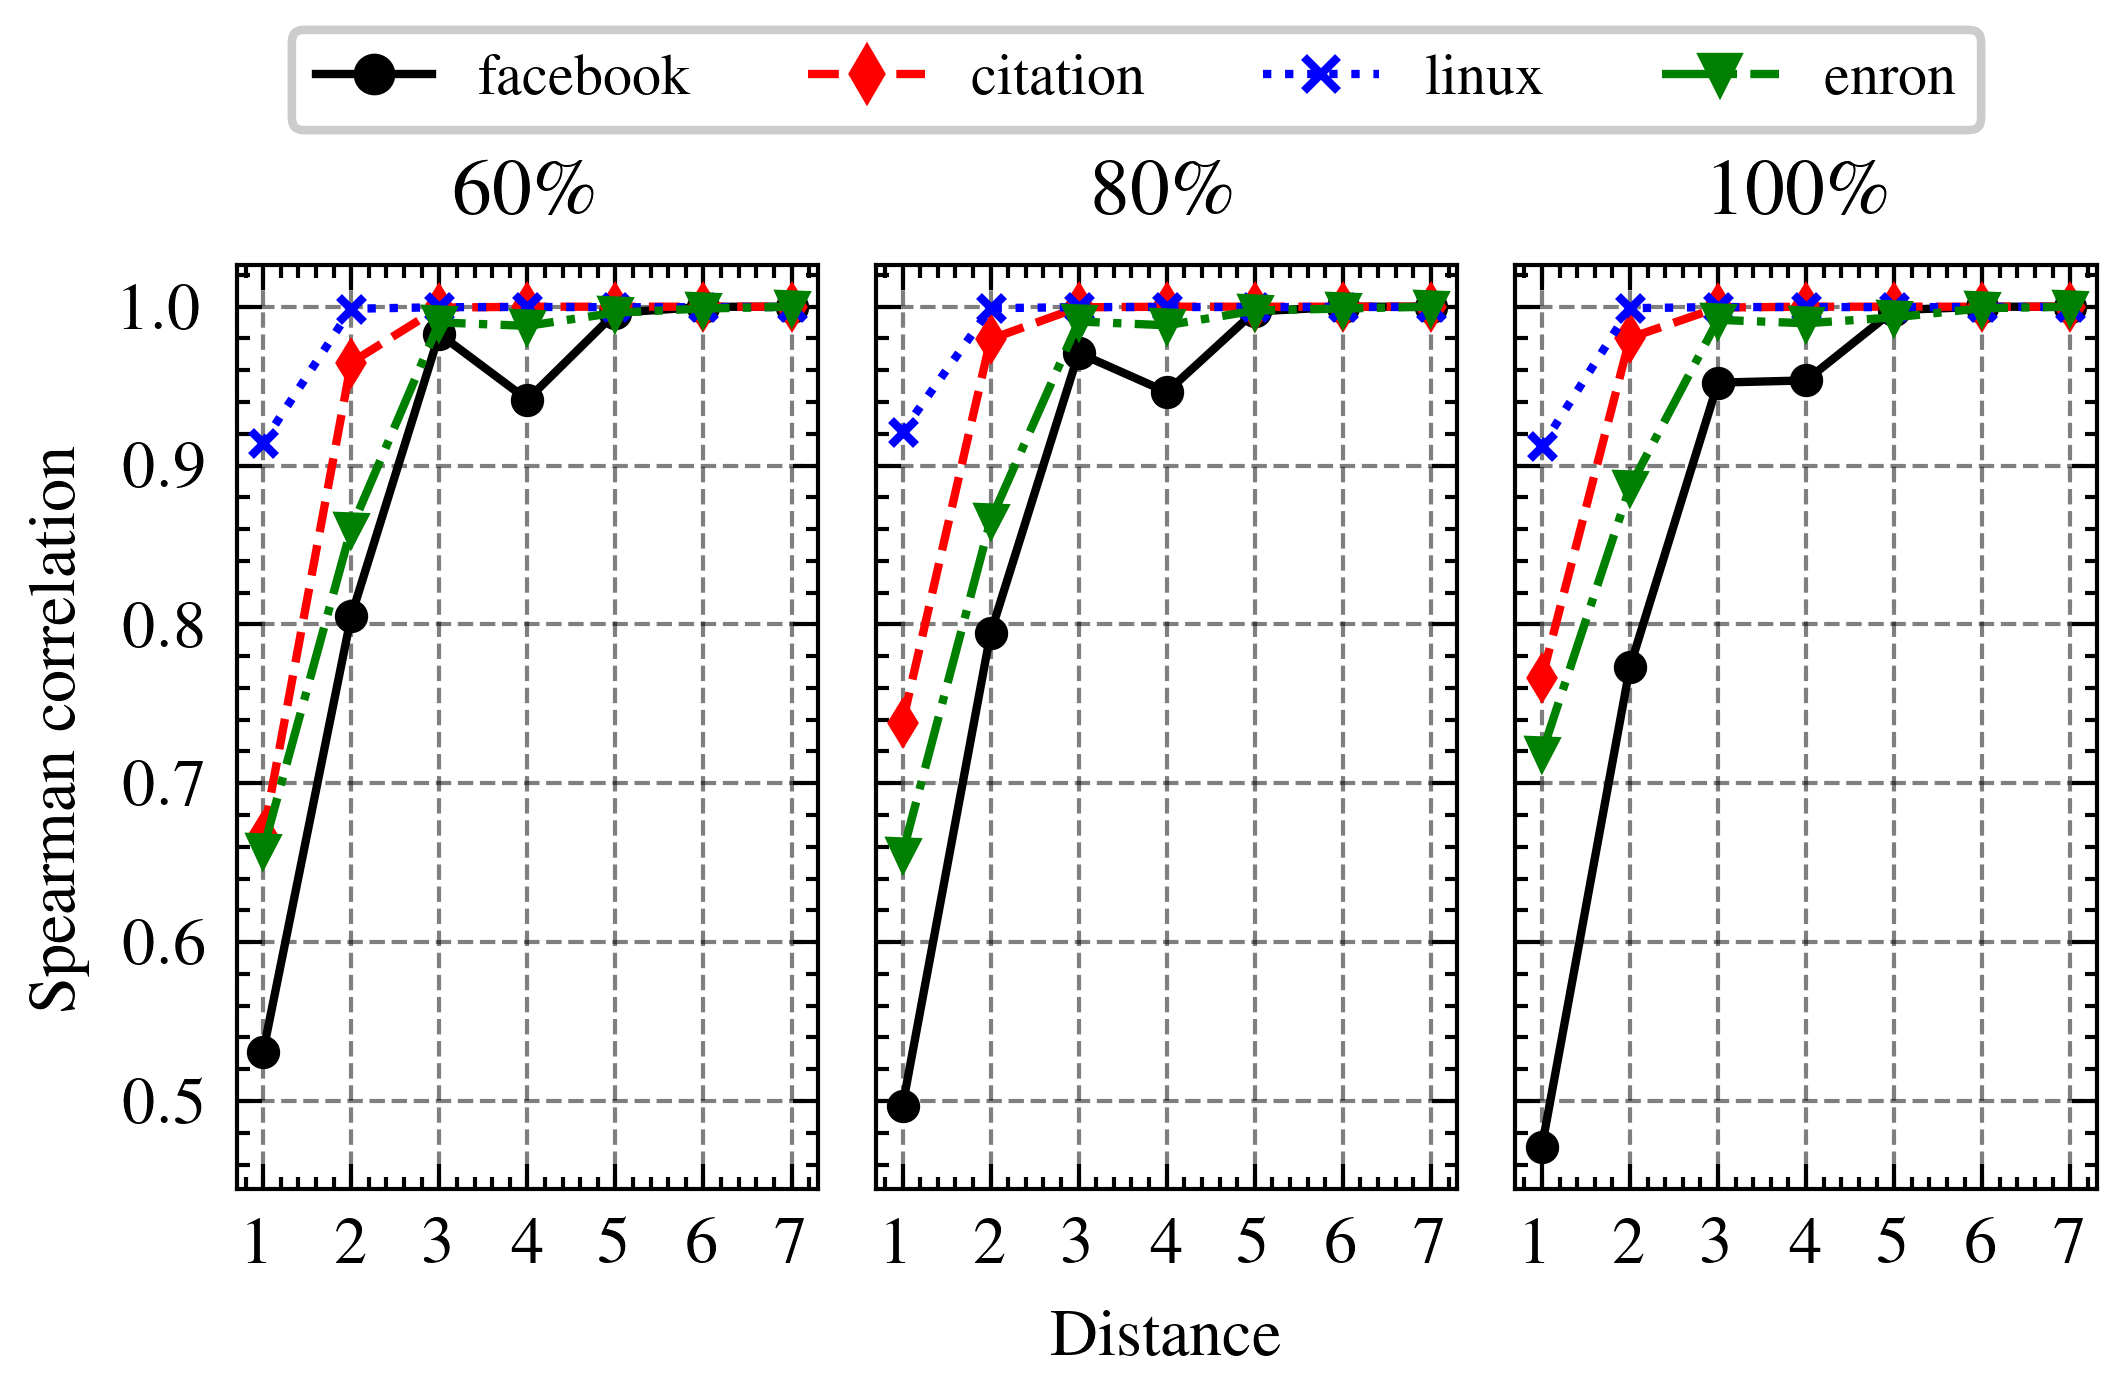

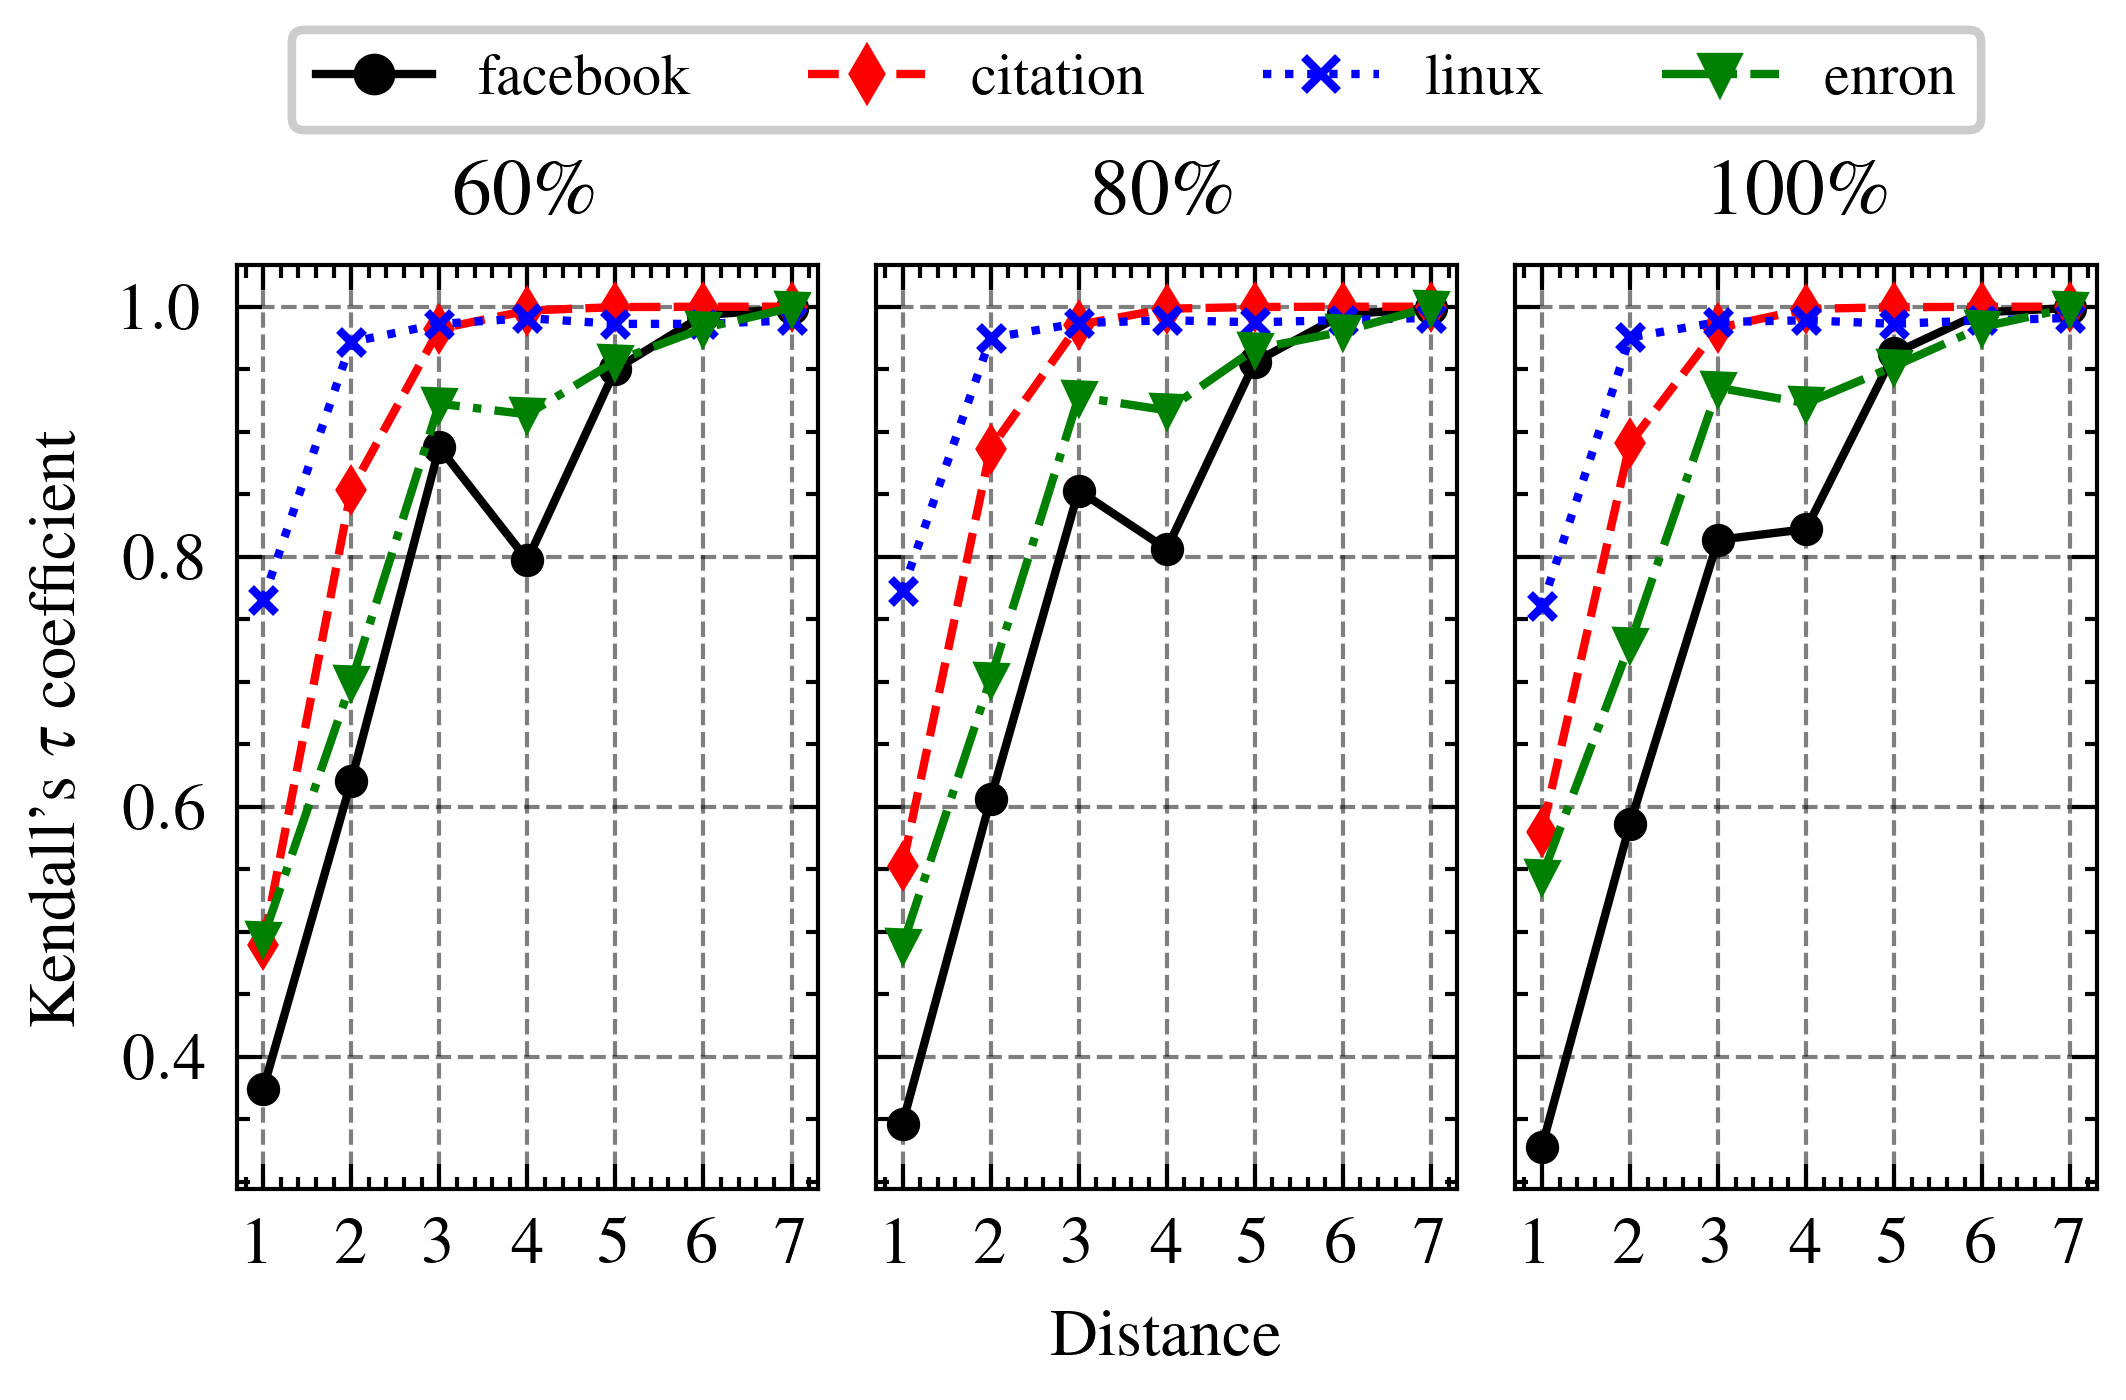

In [43]:
plot_truncated_distances(spearmanr)
plot_truncated_distances(kendalltau)

# PLOT2

In [44]:
data = dict()

for ds in DATASETS:
    data[ds] = dict()
    for alpha in TIME_STAMPS:
        layers = load_layers(ds, alpha)
        hc = harmonic_centrality(layers)
        trunc_hc = harmonic_centrality(layers, trunc=2)
        apx_hc = harmonic_centrality(load_layers(ds, alpha, apx=True))
        data[ds][alpha] = sorted(zip(hc, apx_hc, trunc_hc), key=lambda x: x[0], reverse=True)

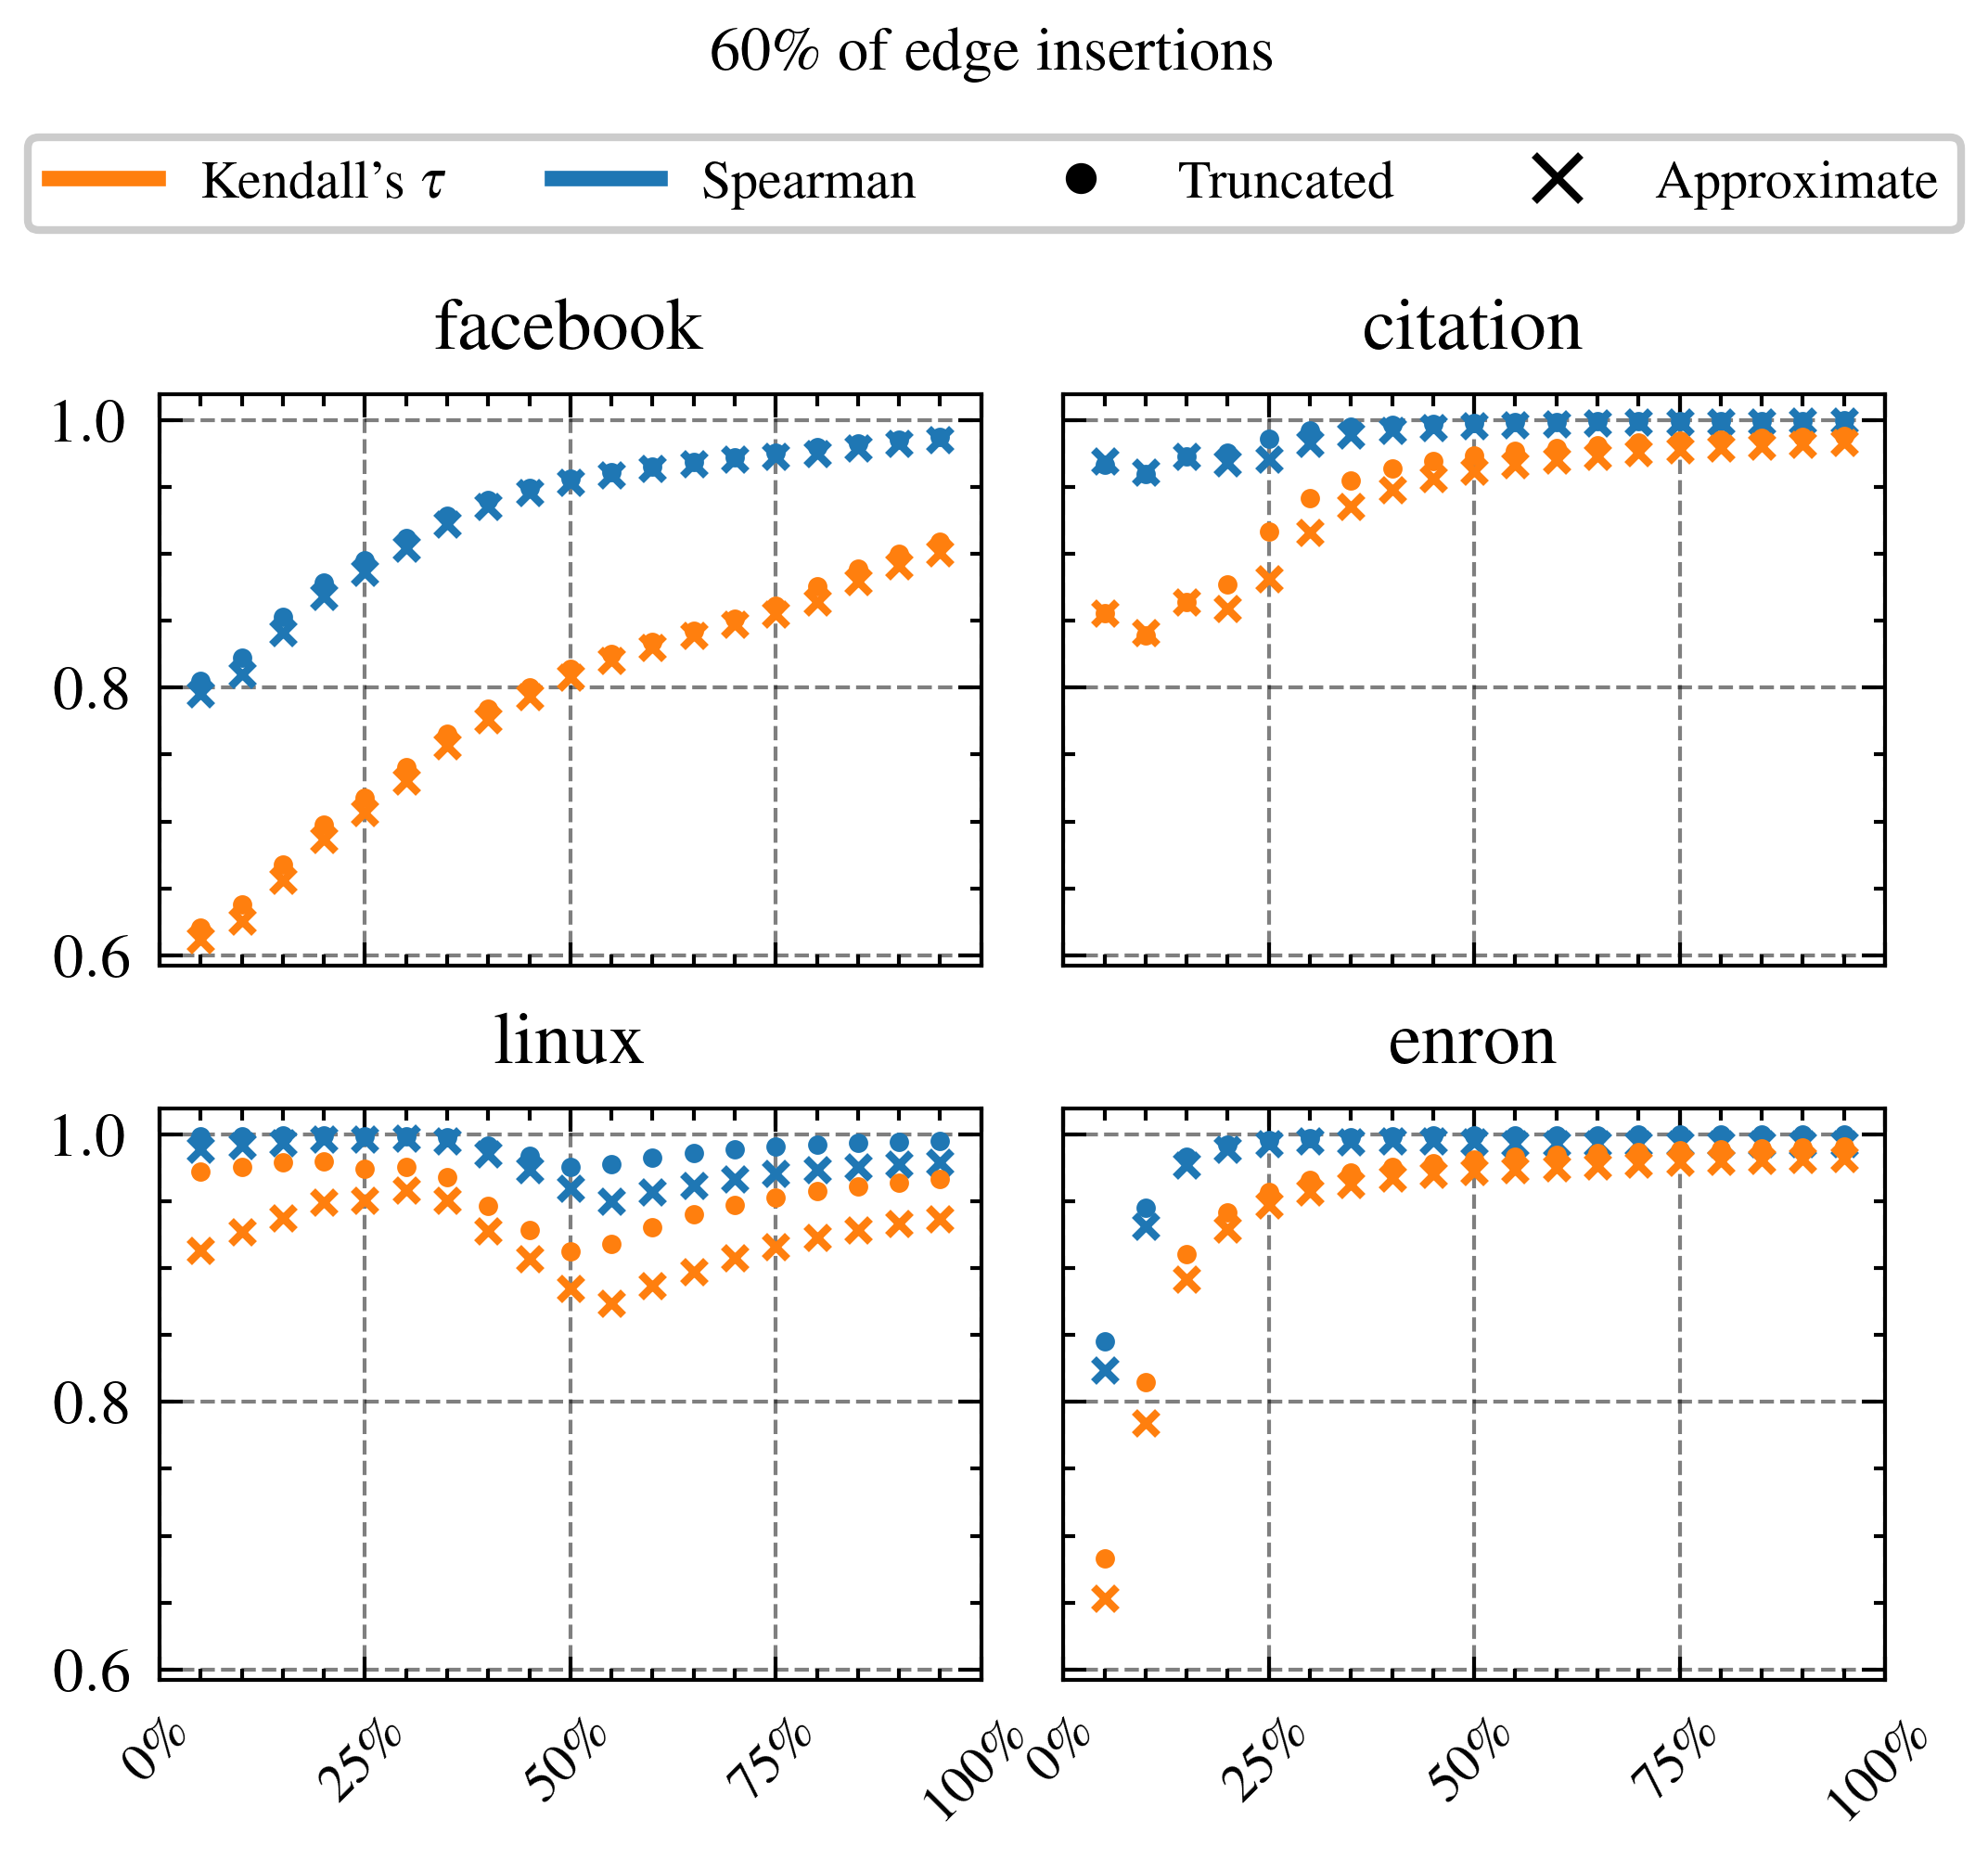

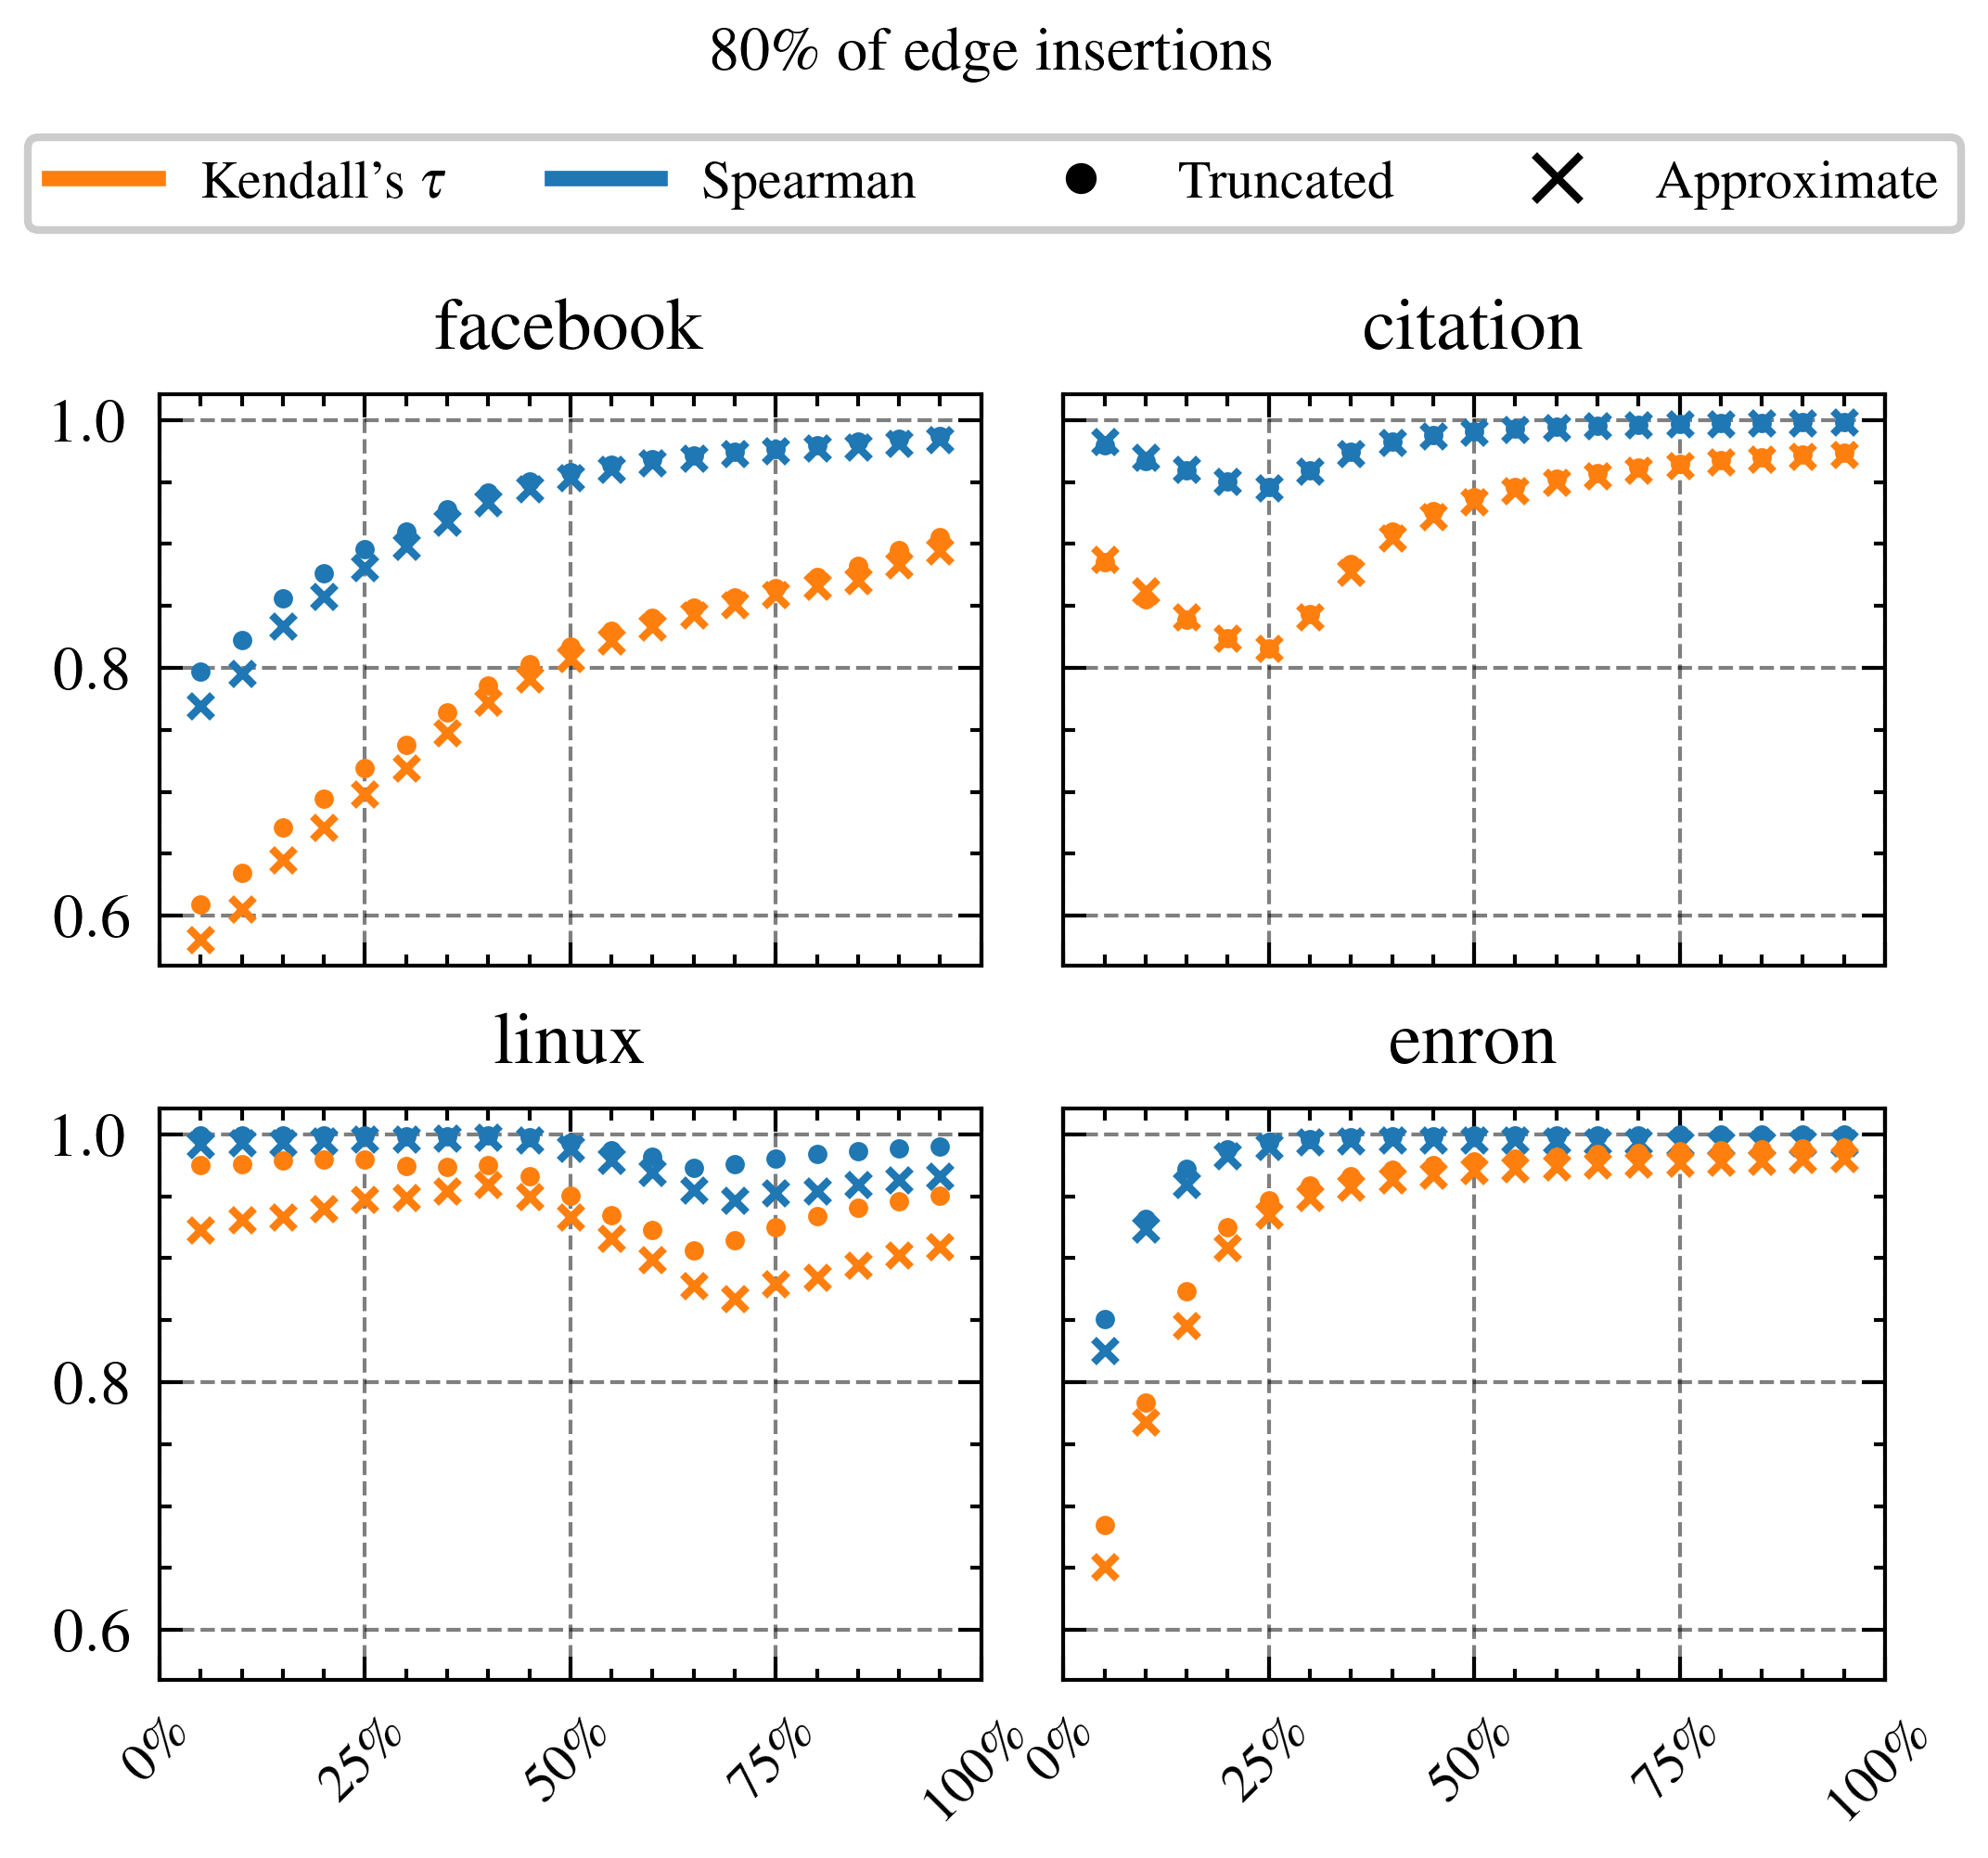

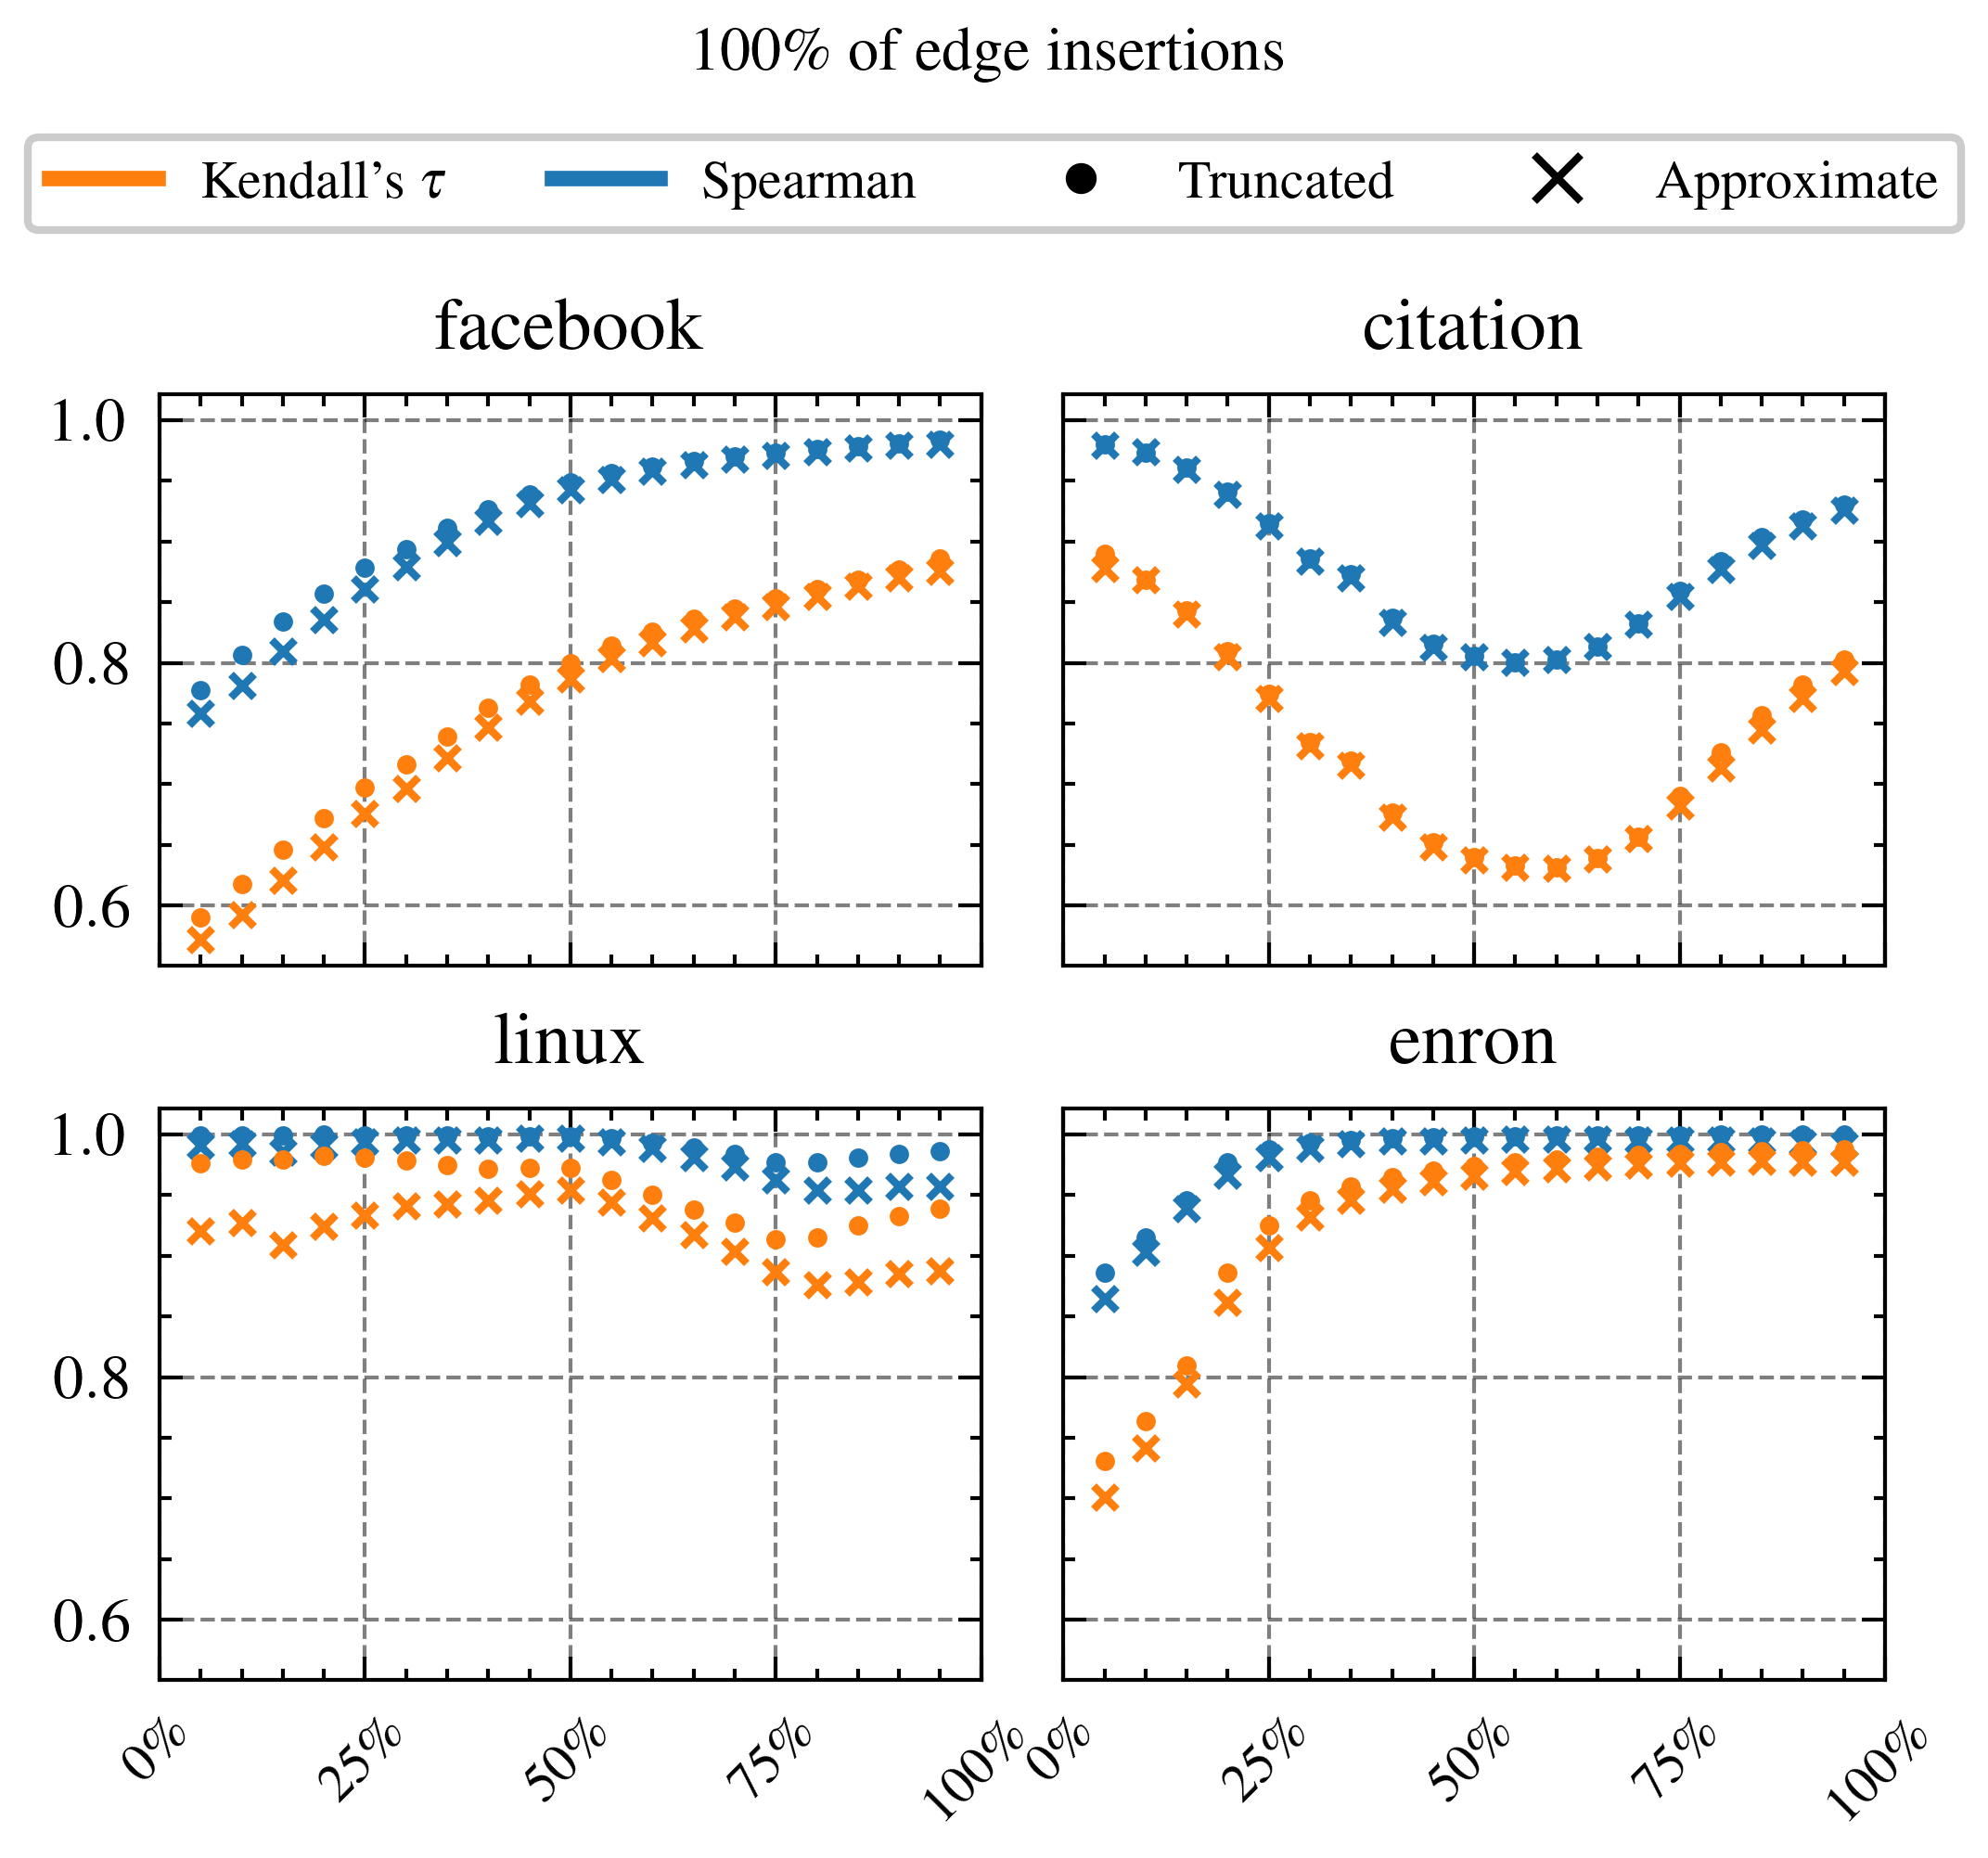

In [45]:

def plot_correlations(alpha: float = 1.0):
    ps = np.linspace(0.0, 1.0, 20)
    fig, ax = plt.subplots(2, 2, figsize=(4, 3), sharex=True, sharey=True)
    fig.subplots_adjust(hspace=0.25, wspace=0.1)

    lw = 0.6
    ms = 3

    for i, ds in enumerate(DATASETS):
        ax[i // 2, i % 2].set_title(SHORT_NAMES[ds])

        y1, y2, y3, y4 = [], [], [], []
        for p in ps:
            hc, apx_hc, trunc_hc = zip(*data[ds][alpha])
            k = int(len(hc) * p)

            y1.append(spearmanr(hc[:k], apx_hc[:k]).statistic)
            y2.append(kendalltau(hc[:k], apx_hc[:k]).statistic)
            y3.append(spearmanr(hc[:k], trunc_hc[:k]).statistic)
            y4.append(kendalltau(hc[:k], trunc_hc[:k]).statistic)

        ax[i // 2, i % 2].plot(
            y1,
            color="tab:blue",
            marker="x",
            markersize=ms,
            # linestyle="-.",
            linestyle="",
            linewidth=lw,
        )

        ax[i // 2, i % 2].plot(
            y2,
            color="tab:orange",
            marker="x",
            markersize=ms,
            # linestyle="--",
            linestyle="",
            linewidth=lw,
        )

        ax[i // 2, i % 2].plot(
            y3,
            color="tab:blue",
            marker=".",
            markersize=ms,
            # linestyle="-.",
            linestyle="",
            linewidth=lw,
        )

        ax[i // 2, i % 2].plot(
            y4,
            color="tab:orange",
            marker=".",
            markersize=ms,
            # linestyle="--",
            linestyle="",
            linewidth=lw,
        )

        ax[i // 2, i % 2].set_xticks(
            [0, 5, 10, 15, 20], [f"{int(x*100)}\%" for x in [0, 0.25, 0.5, 0.75, 1]]
        )
        ax[i // 2, i % 2].tick_params(axis="x", labelsize=7, rotation=45)

    fig.legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                label="Kendall's $\\tau$",
                color="tab:orange",
                linewidth=2,
            ),
            plt.Line2D(
                [0],
                [0],
                label="Spearman",
                color="tab:blue",
                linewidth=2,
            ),
            plt.Line2D(
                [0],
                [0],
                label="Truncated",
                marker=".",
                linestyle="",
                color="k",
            ),
            plt.Line2D(
                [0],
                [0],
                label="Approximate",
                marker="x",
                linestyle="",
                color="k",
            ),
        ],
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 1.05),
        fontsize=7,
    )

    fig.suptitle(
        f"{int(alpha*100)}\% of edge insertions",
        fontsize=8,
        y=1.1,
    )

    plt.show()

plot_correlations(0.6)
plot_correlations(0.8)
plot_correlations(1)

# PLOT3

In [50]:
time_stamps = [0.6, 0.8, 1.0]
data = {
    ds: {
        alpha: {
            "hc": [
                i
                for i, _ in sorted(
                    enumerate(harmonic_centrality(load_layers(ds, alpha))),
                    key=lambda x: x[1],
                    reverse=True,
                )
            ],
            "apx": [
                i
                for i, _ in sorted(
                    enumerate(harmonic_centrality(load_layers(ds, alpha, apx=True))),
                    key=lambda x: x[1],
                    reverse=True,
                )
            ],
        }
        for alpha in time_stamps
    }
    for ds in DATASETS
}

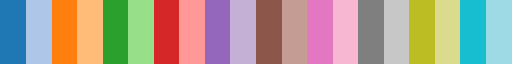

In [65]:
plt.cm.tab20

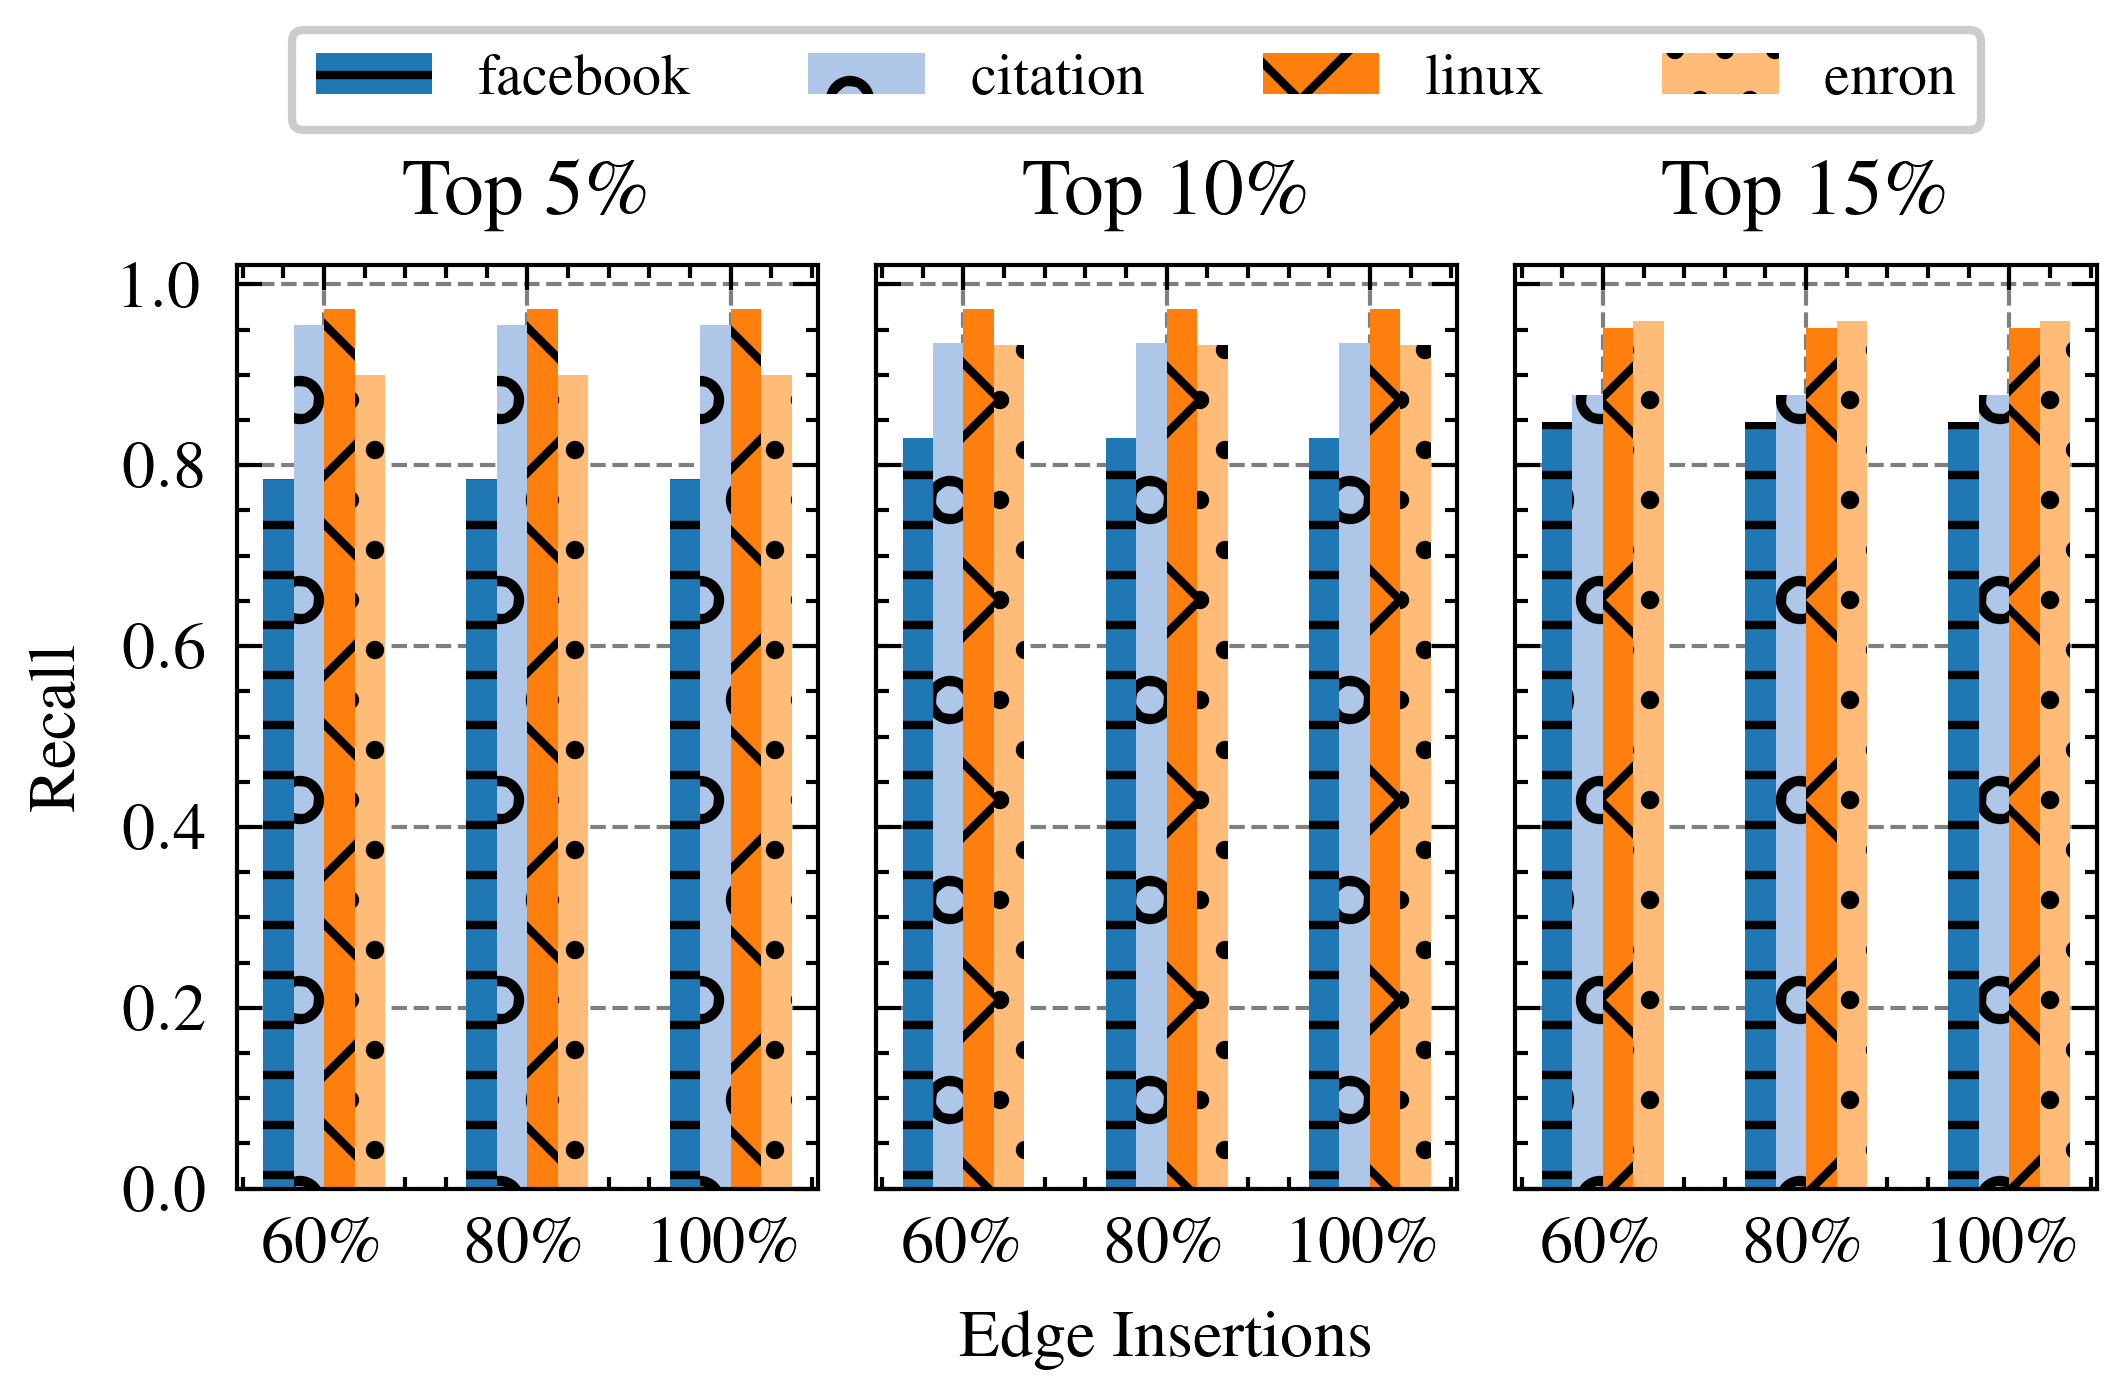

In [89]:
ps = [0.05, 0.1, 0.15]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(4, 2), sharey=True)
fig.subplots_adjust(wspace=0.1)

p = 0.05
recall = lambda eff, ret: len(set(eff) & set(ret)) / len(eff)
jaccard = lambda eff, ret: len(set(eff) & set(ret)) / len(set(eff) | set(ret))

w = 0.15
x = np.array(list(range(len(time_stamps))))

# colors = [
#     "tab:blue",
#     "tab:orange",
#     "tab:green",
#     "tab:purple"
# ]
colors = plt.cm.tab20.colors[:4]
offsets = [-3 / 2, -1 / 2, 1 / 2, 3 / 2]
hatch = ["--", "o", "x", ".."]


for j, p in enumerate(ps):
    for i, ds in enumerate(DATASETS):

        n = len(data[ds][time_stamps[j]]["hc"])

        y = recall(
            data[ds][time_stamps[j]]["hc"][: int(p * n)],
            data[ds][time_stamps[j]]["apx"][: int(p * n)],
        )

        ax[j].bar(
            x + w * offsets[i],
            y,
            width=w,
            color=colors[i],
            hatch=hatch[i],
        )

    ax[j].set_title(f"Top {int(p*100)}\%")
    ax[j].set_xticks([0,1,2], ["60\%", "80\%", "100\%"])

ax[0].set_ylabel("Recall")
ax[1].set_xlabel("Edge Insertions")

fig.legend(
    handles=[
        # plt.Line2D(
        mpatches.Patch(
            label=SHORT_NAMES[ds],
            facecolor=colors[i],
            linewidth=2,
            # color=colors[i],
            hatch=hatch[i]
        )
        for i, ds in enumerate(DATASETS)
    ],
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.1),
    fontsize=7,
)

plt.show()